In [ ]:
import os, sys
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define paths for each files 
# workdir is where you have input files and files will be saved 
workdir = "./"

E1_input_merged = workdir + "E1_input_merged.fastq" #offset: 51
E1_noArab_merged = workdir + "E1_noArab_merged.fastq" #offset: 51
E1_withArab_merged = workdir + "E1_withArab_merged.fastq"#offset: 60 
E2_input_merged = workdir + "E2_input_merged.fastq" #offset: 68
E2_noArab_merged = workdir + "E2_noArab_merged.fastq" #offset: 68
E2_withArab_merged = workdir + "E2_withArab_merged.fastq"#offset: 57 

dict_file = workdir + "sgRNA_dict.txt"


In [ ]:
def txt2list(file):
    with open(file) as f:
        lst = f.readlines()
    return lst 

# Create a dictionary of sgRNA library.
def read_dict(file):
    lst = txt2list(file)
    sgRNA_lib = {}
    read = False
    for line in lst:
        if line.startswith(">"):
            library_name = line[1:].strip()
            read = True 
        elif read:
            seq = line[0:24]
            sgRNA_lib[seq] = library_name
            read = False
    return sgRNA_lib

# Function to parse the counts file
def parse_counts_file(file_path):
    with open(file_path, 'r') as file:
        counts = {} # dictionary of counts
        total_count = 0 # start point of total_count is 0
        for line in file:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                string, count = parts
                count = int(count)
                counts[string] = count
                total_count += count
        return counts, total_count

# Listing sgRNA library from merged fastq files.
def gen_muts_from_seqs(lst, off):
    # Initialize an empty list to store library names
    libraries = []
    # Initialize a dictionary to store sequences that do not match the sgRNA library
    libraries_false = {}
    # Counter for the number of reads processed
    num = 0
    # Counter for the number of "weird" sequences (unmatched sequences)
    weird_count = 1
    # Flag to indicate whether the next line contains a sequence
    read = False
    # Iterate through each line in the input list
    for line in lst:
        # If the line starts with "@", it indicates the start of a new read
        if line.startswith("@"):
            num += 1  # Increment the read counter
            read = True  # Set the flag to read the next line
        # If the flag is set, process the sequence line
        elif read:
            # Extract the sequence from the specified offset
            seq = line[off:24+off]
            try:
                # Try to find the sequence in the sgRNA library
                library_name = sgRNA_lib[seq]
                # If found, append the library name to the list
                libraries.append(library_name)
                read = False  # Reset the flag
            except KeyError:
                # If the sequence is not found in the sgRNA library
                # Add it to the "weird" sequences dictionary with a unique identifier
                libraries_false[seq] = f"weird_{weird_count}"
                weird_count += 1  # Increment the "weird" sequence counter
                read = False  # Reset the flag
    # Calculate the number of unique sequences in the sgRNA library
    original_count = len(set(sgRNA_lib.keys()))
    # Calculate the number of unique library names found in the input list
    unique_items_count = len(set(libraries))
    # Calculate the number of unique "weird" sequences
    weird_items_count = len(set(libraries_false.keys()))
    # Print statistics about the processed data
    print("Number of unique items that should be included: ", original_count)
    print("Number of unique items in the library list: ", unique_items_count)
    print("Number of weird items in the library list: ", weird_items_count)
    print("Read Num: ", num)
    print("Weird read num: ", weird_count)
    # Return the list of library names and the dictionary of "weird" sequences
    return libraries, libraries_false

# Define a custom sort key function
def sort_key(string):
    try:
        # Try to convert to a float
        return (0, float(string[10:12]))
    except ValueError:
        # If it's not a number, sort alphabetically but after numbers
        return (1, string)

def sort_value(string):
    try:
        # Try to convert to a float
        return (0, float(string[10:12]))
    except ValueError:
        # If it's not a number, sort alphabetically but after numbers
        return (1, string)

In [ ]:
#Load the sgRNA library barcode ids
sgRNA_lib = read_dict(dict_file)
sgRNA_lib

{'ATTATTATTTTTGACACCAGACCA': 'LacZ_01',
 'TCCATCAGTTGCTGTTGACTGTAG': 'LacZ_02',
 'GCTGTTGACTGTAGCGGCTGATGT': 'LacZ_03',
 'GACTGTAGCGGCTGATGTTGAACT': 'LacZ_04',
 'GAACTGGAAGTCGCCGCGCCACTG': 'LacZ_05',
 'TTCGCTCGGGAAGACGTACGGGGT': 'LacZ_06',
 'TTCTTGCGGCCCTAATCCGAGCCA': 'LacZ_07',
 'TACCCGCTCTGCTACCTGCGCCAG': 'LacZ_08',
 'CAGGCCAATCCGCGCCGGATGCGG': 'LacZ_09',
 'TTCCGGCTGATAAATAAGGTTTTC': 'LacZ_10',
 'TTCCCCTGATGCTGCCACGCGTGA': 'LacZ_11',
 'CGACCCAGGCGTTAGGGTCAATGC': 'LacZ_12',
 'AGGGTCAATGCGGGTCGCTTCACT': 'LacZ_13',
 'ATCCAGCGGTGCACGGGTGAACTG': 'LacZ_14',
 'GTTTTTTATCGCCAATCCACATCT': 'LacZ_15',
 'TTTTATCGCCAATCCACATCTGTG': 'LacZ_16',
 'AAATTGCCAACGCTTATTACCCAG': 'LacZ_17',
 'TTCCGCCAGACGCCACTGCTGCCA': 'LacZ_18',
 'CGGTTGCACTACGCGTACTGTGAG': 'LacZ_19',
 'GCACTACGCGTACTGTGAGCCAGA': 'LacZ_20',
 'GCCCGGCGCTCTCCGGCTGCGGTA': 'LacZ_21',
 'CAGGCAGTTCAATCAACTGTTTAC': 'LacZ_22',
 'CAATCAACTGTTTACCTTGTGGAG': 'LacZ_23',
 'TACCTTGTGGAGCGACATCCAGAG': 'LacZ_24',
 'ATCGCTATGACGGAACAGGTATTC': 'LacZ_25',


In [79]:
# Generate dictionaries of sgRNA library from the merged fastq files
E1_input_lst = txt2list(E1_input_merged)#offset: 51
E1_noArab_lst = txt2list(E1_noArab_merged)#offset: 51
E1_withArab_lst = txt2list(E1_withArab_merged)#offset: 60 
E2_input_lst = txt2list(E2_input_merged)#offset: 68
E2_noArab_lst = txt2list(E2_noArab_merged)#offset: 68
E2_withArab_lst = txt2list(E2_withArab_merged)#offset: 57 


In [ ]:
"""
generate list  that has identified variant names as components  
The offset should be based on the erged sequencing file
Count the number of bases before the beginning of the variable region and use that number as off value  
"""
E1_input = gen_muts_from_seqs(E1_input_lst,51)
E1_noArab = gen_muts_from_seqs(E1_noArab_lst,51) 
E1_withArab = gen_muts_from_seqs(E1_withArab_lst,60) 
E2_input = gen_muts_from_seqs(E2_input_lst,68) 
E2_noArab = gen_muts_from_seqs(E2_noArab_lst,68) 
E2_withArab = gen_muts_from_seqs(E2_withArab_lst,57) 

Number of unique items that should be included:  109
Number of unique items in the library list:  109
Number of weird items in the library list:  16897
Read Num:  1184066
Weird read num:  68013


In [114]:
import matplotlib.pyplot as plt
from collections import Counter

# count each variant

E1_input_counts = Counter(E1_input[0])
E2_input_counts = Counter(E2_input[0])
E1_noArab_counts = Counter(E1_noArab[0])
E2_noArab_counts = Counter(E2_noArab[0])
E1_withArab_counts = Counter(E1_withArab[0])
E2_withArab_counts = Counter(E2_withArab[0])

# generate txt files of variant-read count
sorted_E1_input_counts = dict(sorted(E1_input_counts.items(), key=lambda item: sort_key(item[0])))
with open(workdir+'E1_input_counts.txt', 'w') as file:
    for string, count in sorted_E1_input_counts.items():
        file.write(f"{string}\t{count}\n")
        
sorted_E2_input_counts = dict(sorted(E2_input_counts.items(), key=lambda item: sort_key(item[0])))
with open(workdir+'E2_input_counts.txt', 'w') as file:
    for string, count in sorted_E2_input_counts.items():
        file.write(f"{string}\t{count}\n")
        
sorted_E1_noArab_counts = dict(sorted(E1_noArab_counts.items(), key=lambda item: sort_key(item[0])))
with open(workdir+'E1_noArab_counts.txt', 'w') as file:
    for string, count in sorted_E1_noArab_counts.items():
        file.write(f"{string}\t{count}\n")
        
sorted_E2_noArab_counts = dict(sorted(E2_noArab_counts.items(), key=lambda item: sort_key(item[0])))
with open(workdir+'E2_noArab_counts.txt', 'w') as file:
    for string, count in sorted_E2_noArab_counts.items():
        file.write(f"{string}\t{count}\n")
        
sorted_E1_withArab_counts = dict(sorted(E1_withArab_counts.items(), key=lambda item: sort_key(item[0])))
with open(workdir+'E1_withArab_counts.txt', 'w') as file:
    for string, count in sorted_E1_withArab_counts.items():
        file.write(f"{string}\t{count}\n")
        
sorted_E2_withArab_counts = dict(sorted(E2_withArab_counts.items(), key=lambda item: sort_key(item[0])))
with open(workdir+'E2_withArab_counts.txt', 'w') as file:
    for string, count in sorted_E2_withArab_counts.items():
        file.write(f"{string}\t{count}\n")
print("Files have been created.")

Files have been created.


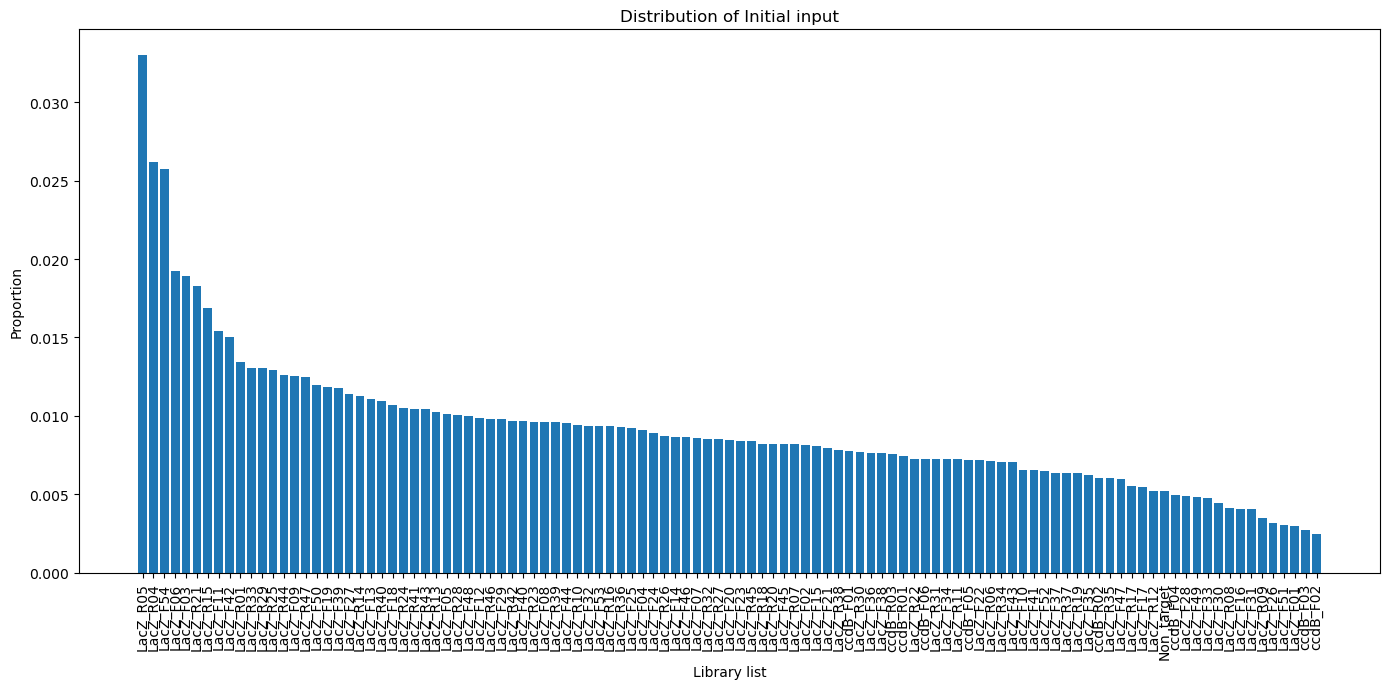

In [115]:
# distribution of variants
import matplotlib.pyplot as plt

init_total = sum(sorted_E1_input_counts.values())
init_proportions = {key: value / init_total for key, value in sorted_E1_input_counts.items()}
init_sorted_proportions = dict(sorted(init_proportions.items(), key=lambda item: item[1], reverse=True))

# Create bar plot
plt.figure(figsize=(14, 7))  # You might want to adjust the size depending on the number of unique strings
plt.bar(init_sorted_proportions.keys(), init_sorted_proportions.values())

# Add labels and title (optional)
plt.xlabel('Library list')
plt.ylabel('Proportion')
plt.title('Distribution of Initial input')

# plt.ylim(0,0.145)
plt.xticks(rotation=90)  # Rotate the x labels so they don't overlap

# Show plot
plt.tight_layout()  # Adjust the padding between and around subplots.
plt.show()



data reading is done


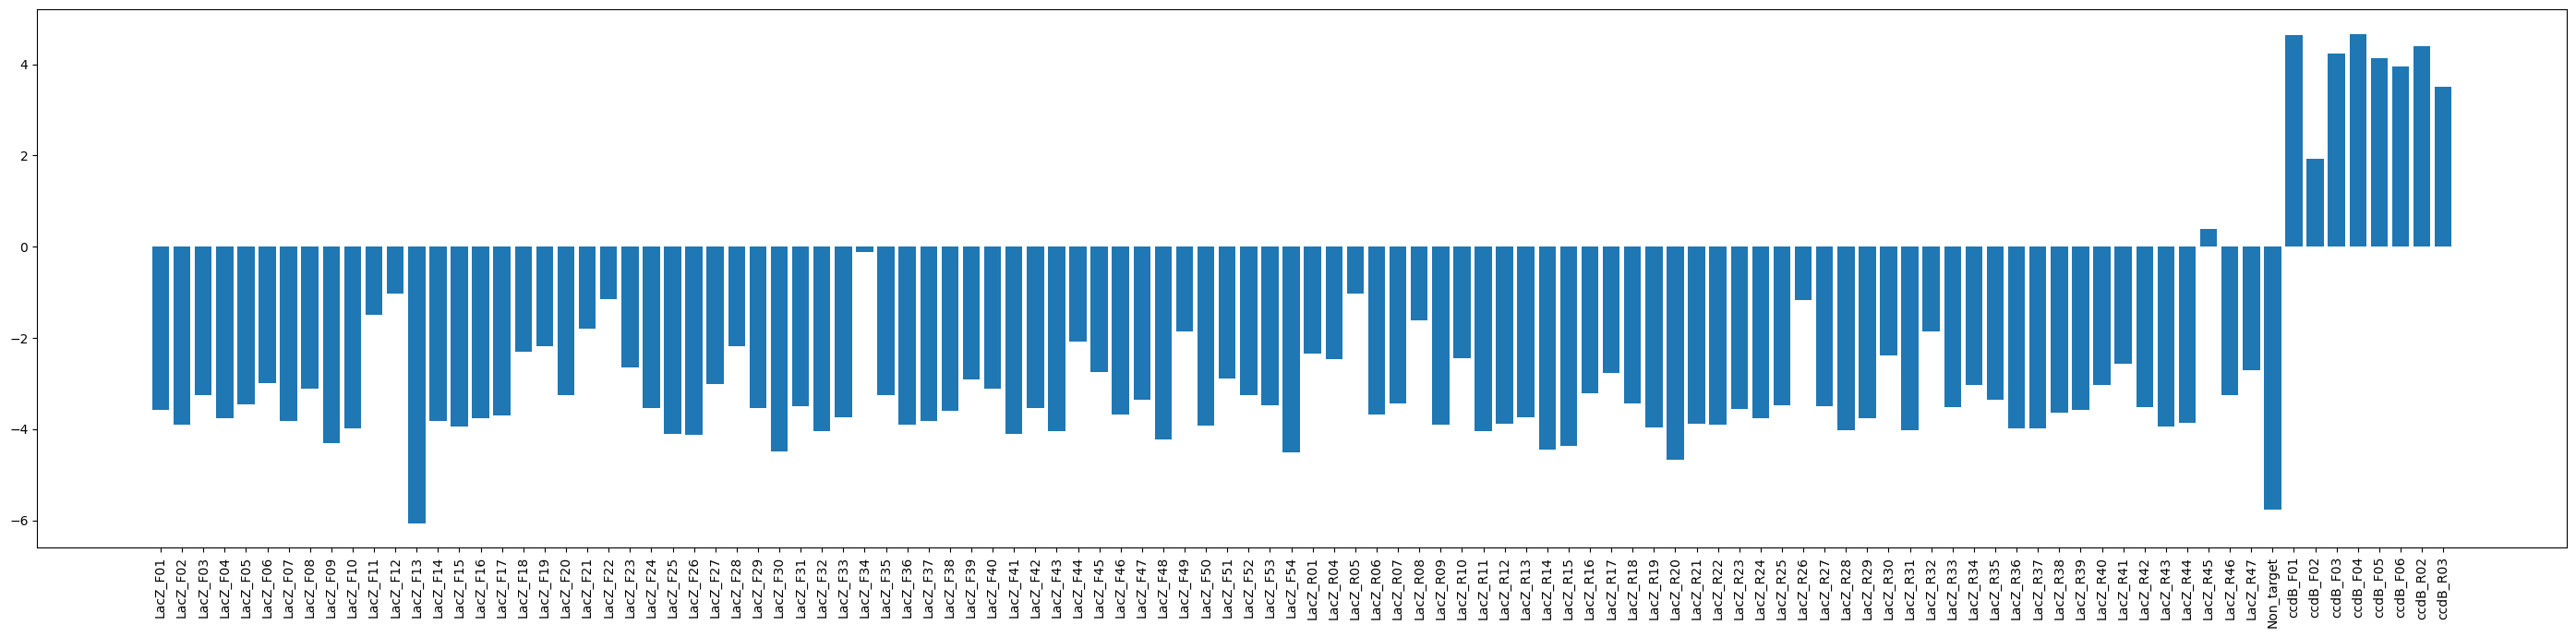

In [26]:
# ES Plotting (replicate 1)
import math

E1_input_counts_txt = workdir+'0124_E1_input_counts.txt'
E2_input_counts_txt = workdir+'0124_E2_input_counts.txt'

E1_noArab_counts_txt = workdir+'0124_E1_noArab_counts.txt'
E2_noArab_counts_txt = workdir+'0124_E2_noArab_counts.txt'

E1_withArab_counts_txt = workdir+'0124_E1_withArab_counts.txt'
E2_withArab_counts_txt = workdir+'0124_E2_withArab_counts.txt'

counts1, total1 = parse_counts_file(E1_noArab_counts_txt)
# path for the generated unique_muts_counts.txt file for output 
counts2, total2 = parse_counts_file(E1_withArab_counts_txt)
comparison_results = {}

data_string = []
scores = []
for string in sorted(set(counts1.keys()).union(counts2.keys())):
    rel_amount1 = counts1.get(string, 0) / total1 if total1 else 0
    rel_amount2 = counts2.get(string, 0) / total2 if total2 else 0
    comparison = math.log2(rel_amount2 / rel_amount1) if rel_amount2 and rel_amount1 > 0 else float('nan')  # Avoid division by zero
    if total1*total2*rel_amount2 == 0:
        print(string,"was problem")
    comparison_results[string] = comparison
    data_string.append(string)
    scores.append(comparison)
print("data reading is done")

plt.figure(figsize=(28, 7))
d = {"Strings": data_string, "Enrichment scores":scores}
plt.bar(data_string,scores)
plt.xticks(rotation=90) 
plt.tight_layout()
plt.show()


data reading is done


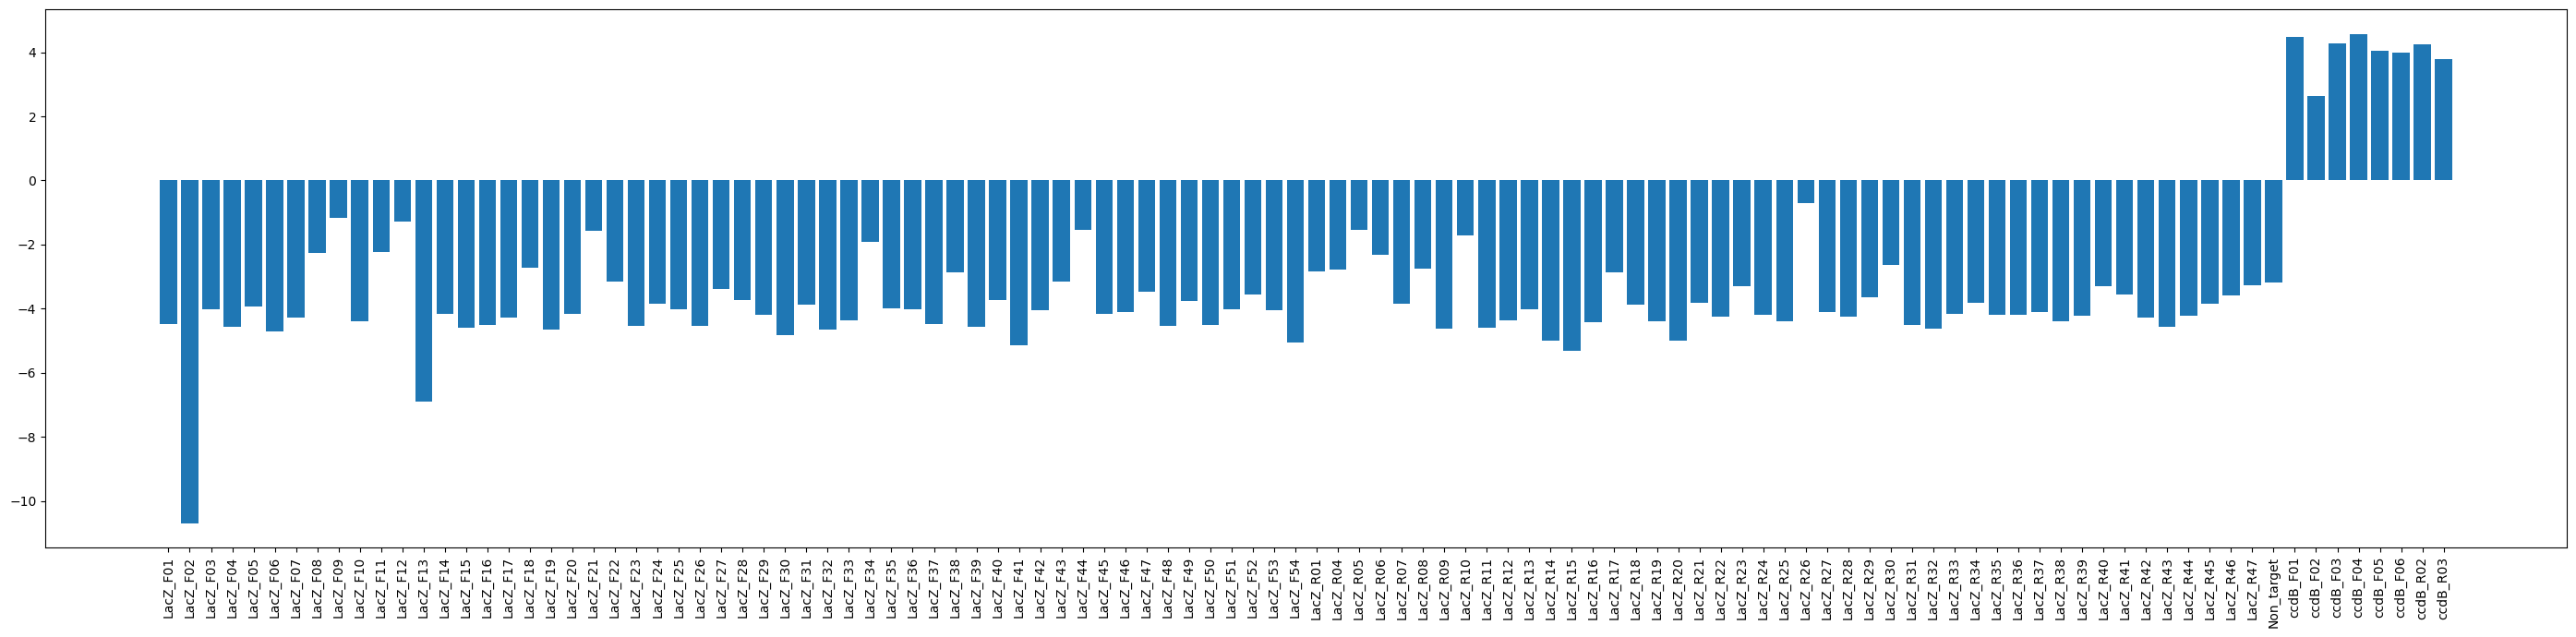

In [30]:
# ES Plotting (replicate 2)
import math

E1_input_counts_txt = workdir+'0124_E1_input_counts.txt'
E2_input_counts_txt = workdir+'0124_E2_input_counts.txt'

E1_noArab_counts_txt = workdir+'0124_E1_noArab_counts.txt'
E2_noArab_counts_txt = workdir+'0124_E2_noArab_counts.txt'

E1_withArab_counts_txt = workdir+'0124_E1_withArab_counts.txt'
E2_withArab_counts_txt = workdir+'0124_E2_withArab_counts.txt'

counts1, total1 = parse_counts_file(E2_noArab_counts_txt)
# path for the generated unique_muts_counts.txt file for output 
counts2, total2 = parse_counts_file(E2_withArab_counts_txt)
comparison_results = {}

data_string = []
scores = []
for string in sorted(set(counts1.keys()).union(counts2.keys())):
    rel_amount1 = counts1.get(string, 0) / total1 if total1 else 0
    rel_amount2 = counts2.get(string, 0) / total2 if total2 else 0
    comparison = math.log2(rel_amount2 / rel_amount1) if rel_amount2 and rel_amount1 > 0 else float('nan')  # Avoid division by zero
    if total1*total2*rel_amount2 == 0:
        print(string,"was problem")
    comparison_results[string] = comparison
    data_string.append(string)
    scores.append(comparison)
print("data reading is done")

plt.figure(figsize=(28, 7))
d = {"Strings": data_string, "Enrichment scores":scores}
plt.bar(data_string,scores)
plt.xticks(rotation=90) 
plt.tight_layout()
plt.show()


data reading is done for first set
Length of scores_1: 108
data reading is done for second set 
Length of scores_2: 108


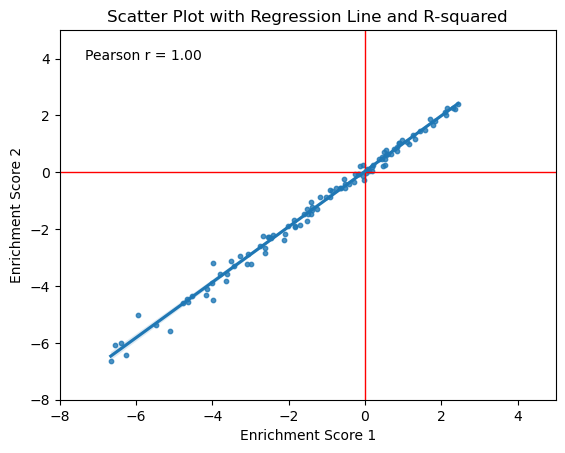

In [ ]:
# ES-activity, Scatter plot (not normalized)

from scipy import stats
import pandas as pd
import math

#for scatter plot
# path for the generated unique_muts_counts.txt file for input 
counts1, total1 = parse_counts_file(E1_input_counts_txt)
# path for the generated unique_muts_counts.txt file for output 
counts2, total2 = parse_counts_file(E1_noArab_counts_txt)
comparison_results = {}

scores_1 = [] 
for string in sorted(set(counts1.keys()).union(counts2.keys())):
    rel_amount1 = counts1.get(string, 0) / total1 if total1 else 0
    rel_amount2 = counts2.get(string, 0) / total2 if total2 else 0
    comparison = math.log2(rel_amount2 / rel_amount1) if rel_amount2 and rel_amount1 > 0 else float('nan')  # Avoid division by zero
    comparison_results[string] = comparison
    data_string.append(string)
    scores_1.append(comparison)
print("data reading is done for first set")
print("Length of scores_1:", len(scores_1))

# path for the generated unique_muts_counts.txt file for input 
counts1, total1 = parse_counts_file(E2_input_counts_txt)
# path for the generated unique_muts_counts.txt file for output 
counts2, total2 = parse_counts_file(E2_noArab_counts_txt)
comparison_results = {}

scores_2 = [] 
for string in sorted(set(counts1.keys()).union(counts2.keys())):
    rel_amount1 = counts1.get(string, 0) / total1 if total1 else 0
    rel_amount2 = counts2.get(string, 0) / total2 if total2 else 0
    comparison = math.log2(rel_amount2 / rel_amount1) if rel_amount2 and rel_amount1 > 0 else float('nan')
    comparison_results[string] = comparison
    data_string.append(string)
    scores_2.append(comparison)
print("data reading is done for second set ")
print("Length of scores_2:", len(scores_2))

if len(scores_1) > len(scores_2):
    scores_2.append(np.nan)

# Convert scores to a Pandas DataFrame
data_frame = pd.DataFrame({'EnrichmentScore1': scores_1, 'EnrichmentScore2': scores_2})

# Check for NaN or infinite values and handle them
data_frame.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinities with NaN
data_frame.dropna(inplace=True)  # Drop rows with NaN values

# Plotting
plt.axhline(y=0, linewidth=1, color='r')
plt.axvline(x=0, linewidth=1, color='r')

# Adding regression line using regplot
sns.regplot(x="EnrichmentScore1", y="EnrichmentScore2", data=data_frame, scatter_kws={'s':10})

# Calculating R-squared value
pearson_r, _ = stats.pearsonr(data_frame['EnrichmentScore1'], data_frame['EnrichmentScore2'])

# Annotating the plot with R-squared value
plt.text(0.05, 0.95, f'Pearson r = {pearson_r:.2f}', horizontalalignment='left', verticalalignment='top', transform=plt.gca().transAxes)

# Optional: Add labels and title
plt.xlim(-8,5)
plt.ylim(-8,5)
plt.xlabel('Enrichment Score 1')
plt.ylabel('Enrichment Score 2')
plt.title('Scatter Plot with Regression Line and R-squared')

# Show the plot
plt.show()

data reading is done for first set
Length of scores_1: 108
data reading is done for second set 
Length of scores_2: 108


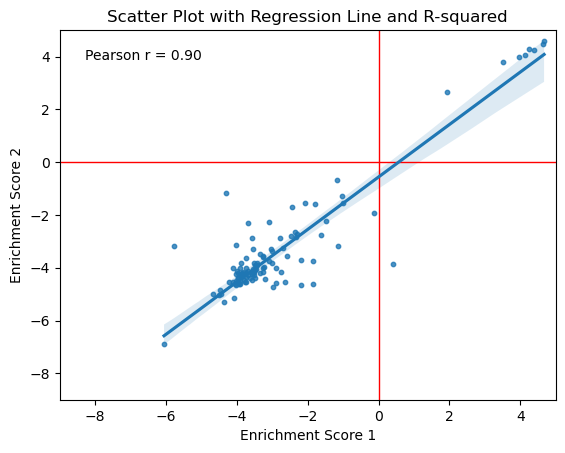

In [ ]:
# ES-specificity, Scatter plot

# path for the generated unique_muts_counts.txt file for input 
counts1, total1 = parse_counts_file(E1_noArab_counts_txt)
# path for the generated unique_muts_counts.txt file for output 
counts2, total2 = parse_counts_file(E1_withArab_counts_txt)
comparison_results = {}

scores_1 = [] 
for string in sorted(set(counts1.keys()).union(counts2.keys())):
    rel_amount1 = counts1.get(string, 0) / total1 if total1 else 0
    rel_amount2 = counts2.get(string, 0) / total2 if total2 else 0
    comparison = math.log2(rel_amount2 / rel_amount1) if rel_amount2 and rel_amount1 > 0 else float('nan')  # Avoid division by zero
    comparison_results[string] = comparison
    data_string.append(string)
    scores_1.append(comparison)
print("data reading is done for first set")
print("Length of scores_1:", len(scores_1))

# path for the generated unique_muts_counts.txt file for input 
counts1, total1 = parse_counts_file(E2_noArab_counts_txt)
# path for the generated unique_muts_counts.txt file for output 
counts2, total2 = parse_counts_file(E2_withArab_counts_txt)
comparison_results = {}

scores_2 = [] 
for string in sorted(set(counts1.keys()).union(counts2.keys())):
    rel_amount1 = counts1.get(string, 0) / total1 if total1 else 0
    rel_amount2 = counts2.get(string, 0) / total2 if total2 else 0
    comparison = math.log2(rel_amount2 / rel_amount1) if rel_amount2 and rel_amount1 > 0 else float('nan')
    #comparison = math.log2(rel_amount2 / rel_amount1) if rel_amount2 else float('inf')  # Avoid division by zero
    comparison_results[string] = comparison
    data_string.append(string)
    scores_2.append(comparison)
print("data reading is done for second set ")
print("Length of scores_2:", len(scores_2))

if len(scores_1) > len(scores_2):
    scores_2.append(np.nan)

# Convert scores to a Pandas DataFrame
data_frame = pd.DataFrame({'EnrichmentScore1': scores_1, 'EnrichmentScore2': scores_2})

# Check for NaN or infinite values and handle them
data_frame.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinities with NaN
data_frame.dropna(inplace=True)  # Drop rows with NaN values

# Plotting
plt.axhline(y=0, linewidth=1, color='r')
plt.axvline(x=0, linewidth=1, color='r')

# Adding regression line using regplot
sns.regplot(x="EnrichmentScore1", y="EnrichmentScore2", data=data_frame, scatter_kws={'s':10})

# Calculating R-squared value
pearson_r, _ = stats.pearsonr(data_frame['EnrichmentScore1'], data_frame['EnrichmentScore2'])

# Annotating the plot with R-squared value
plt.text(0.05, 0.95, f'Pearson r = {pearson_r:.2f}', horizontalalignment='left', verticalalignment='top', transform=plt.gca().transAxes)

# Optional: Add labels and title
plt.xlim(-9,5)
plt.ylim(-9,5)
plt.xlabel('Enrichment Score 1')
plt.ylabel('Enrichment Score 2')
plt.title('Scatter Plot with Regression Line and R-squared')

# Show the plot
plt.show()